# 2. The computational grid and spectrum

**What this shows:** how to define where SWAN computes (the computational grid) and
how finely it resolves the wave spectrum (the spectral grid), and the conventions for
coordinates and directions.

**Prerequisites:** [1. Your first SWAN model](01_first_model.ipynb).

**You will learn:**

- how `SwanGrid` and `CGRID REGULAR` describe a regular grid, and why SWAN counts
  meshes rather than points
- when to use spherical or Cartesian coordinates
- how to choose the directions and frequencies of the spectral grid
- what the nautical and Cartesian direction conventions mean

**Data used:** `etopo15s_perth.nc` (bathymetry), to show the grid in context.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pydantic import ValidationError

DATA_DIR = Path("../data")

## 1. A regular grid

`SwanGrid` places a regular grid by its lower-left corner (`x0`, `y0`), spacing
(`dx`, `dy`) and number of points (`nx`, `ny`). It is the grid rompy-swan uses to crop
input data and to find boundary points. Here is the grid from Tutorial 1 on top of the
bathymetry.

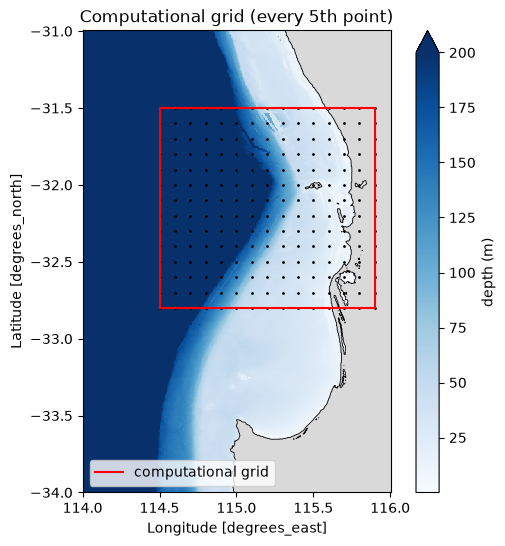

In [2]:
from rompy_swan.grid import SwanGrid

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)

etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
depth = -etopo.z.where(etopo.z < 0)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.set_facecolor("0.85")  # land
depth.plot(ax=ax, cmap="Blues", vmax=200, cbar_kwargs={"label": "depth (m)"})
etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
ax.plot(grid.x[::5, ::5], grid.y[::5, ::5], "k.", markersize=2)
x0, y0, x1, y1 = grid.bbox()
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r", label="computational grid")
ax.legend(loc="lower left")
ax.set_aspect("equal")
ax.set_title("Computational grid (every 5th point)");

`grid.component` converts it into the grid part of SWAN's `CGRID` command. SWAN
describes a grid by its length and number of *meshes* (cells between points), so
`mx` and `my` are one less than `nx` and `ny`.

In [3]:
grid.component

GRIDREGULAR(model_type='gridregular', xp=114.5, yp=-32.8, alp=0.0, xlen=1.4, ylen=1.3, mx=70, my=65, suffix='')

## 2. Spherical or Cartesian coordinates

`COORDINATES` sets how SWAN reads every position in the command file:

- `SPHERICAL()`: longitude and latitude in degrees, as in these tutorials. Use it for
  domains larger than a few tens of kilometres. SWAN requires regular spherical grids
  to be aligned with the meridians (no rotation).
- `CARTESIAN()` (SWAN's default): metres in a projected system, e.g. UTM. The grid can
  be rotated with `rot`, anticlockwise from the x-axis, to align it with the coast.

In [4]:
from rompy_swan.components.startup import COORDINATES
from rompy_swan.subcomponents.startup import CARTESIAN, SPHERICAL

print(COORDINATES(kind=SPHERICAL()).render())
print(COORDINATES(kind=CARTESIAN()).render())

utm_grid = SwanGrid(x0=370000.0, y0=6360000.0, rot=15.0, dx=200.0, dy=200.0, nx=101, ny=81)
utm_grid.component

COORDINATES SPHERICAL CCM
COORDINATES CARTESIAN


GRIDREGULAR(model_type='gridregular', xp=370000.0, yp=6360000.0, alp=15.0, xlen=20000.0, ylen=16000.0, mx=100, my=80, suffix='')

The data and boundary interfaces take coordinates from the datasets as they are. With
Cartesian coordinates, the input data must be in the same projected system as the
grid.

## 3. The spectral grid

SWAN represents the waves at every grid point as a spectrum over directions and
frequencies. `SPECTRUM` sets its resolution:

- `mdc`: the number of directions over the full circle, e.g. 36 gives 10° bins;
- `flow`, `fhigh`: the lowest and highest frequencies. SWAN spaces the frequencies
  logarithmically, about 10% apart, which its quadruplet approximation assumes.

In [5]:
from rompy_swan.subcomponents.spectrum import SPECTRUM

spectrum = SPECTRUM(mdc=36, flow=0.04, fhigh=1.0)
spectrum.render()

'CIRCLE mdc=36 flow=0.04 fhigh=1.0'

With 0.04 to 1 Hz, SWAN uses 34 meshes, i.e. 35 frequencies (Tutorial 1's `PRINT` file
reports `MSC-1 = 34`). Here they are, as periods:

In [6]:
meshes = int(np.ceil(np.log(spectrum.fhigh / spectrum.flow) / np.log(1.1)))
freqs = spectrum.flow * (spectrum.fhigh / spectrum.flow) ** (np.arange(meshes + 1) / meshes)
print(f"{meshes + 1} frequencies, periods from {1 / freqs[0]:.1f} s to {1 / freqs[-1]:.1f} s")
print(np.round(1 / freqs, 1))

35 frequencies, periods from 25.0 s to 1.0 s
[25.  22.7 20.7 18.8 17.1 15.6 14.2 12.9 11.7 10.7  9.7  8.8  8.   7.3
  6.6  6.   5.5  5.   4.5  4.1  3.8  3.4  3.1  2.8  2.6  2.3  2.1  1.9
  1.8  1.6  1.5  1.3  1.2  1.1  1. ]


The [SWAN manual](https://swanmodel.sourceforge.io/online_doc/swanuse/node11.html)
suggests:

| Setting | Guidance |
|---|---|
| Directions | 10–15° for wind sea (`mdc=24` to `36`), 2–5° for narrow swell |
| `flow` | below 0.7 × the lowest peak frequency expected; 0.03–0.04 Hz |
| `fhigh` | 1 Hz is usually enough; at least 2.5–3 × the highest peak frequency |

When all waves come from one side, a `SECTOR` (directions `dir1` to `dir2`) saves
computation. Directions outside the sector are then ignored.

In [7]:
SPECTRUM(mdc=18, dir1=180.0, dir2=360.0, flow=0.04, fhigh=1.0).render()

'SECTOR 180.0 360.0 mdc=18 flow=0.04 fhigh=1.0'

The spectral settings are checked when the object is created:

In [8]:
try:
    SPECTRUM(mdc=36, flow=1.0, fhigh=0.04)
except ValidationError as err:
    print(err)

1 validation error for SPECTRUM
  Value error, flow must be less than fhigh [type=value_error, input_value={'mdc': 36, 'flow': 1.0, 'fhigh': 0.04}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


## 4. Direction conventions

SWAN's default is the Cartesian convention: the direction waves travel *to*,
anticlockwise from the x-axis. `SET NAUTICAL` switches wave and wind directions,
in the command file and in the output, to the direction they come *from*, clockwise
from north. All the notebooks here use the nautical convention.

In [9]:
from rompy_swan.components.startup import SET

SET(direction_convention="nautical").render()

'SET NAUTICAL'

Grid rotations always follow the Cartesian convention, whatever `SET` says.

## 5. The computational grid command

`cgrid.REGULAR` combines the grid and the spectrum into SWAN's `CGRID` command, which
is the only required part of a `SwanConfig`.

In [10]:
from rompy_swan.components.cgrid import REGULAR

cgrid = REGULAR(grid=grid.component, spectrum=spectrum)
print(cgrid.render())

CGRID REGULAR xpc=114.5 ypc=-32.8 alpc=0.0 xlenc=1.4 ylenc=1.3 mxc=70 myc=65 CIRCLE mdc=36 flow=0.04 fhigh=1.0


SWAN also supports curvilinear and unstructured (triangular) grids. rompy-swan can
write those commands, but its data and boundary interfaces only work with regular
grids. See [Grid types](../examples/grid_types.ipynb).

## Summary

- `SwanGrid` places the grid; `grid.component` gives SWAN's meshes and lengths.
- Use spherical coordinates for regional domains (no rotation) and Cartesian for
  local, rotated grids.
- `SPECTRUM` sets the directions and the logarithmic frequencies; 10° and 0.04–1 Hz
  is a good start.
- `SET NAUTICAL` makes directions mean *coming from*, clockwise from north.

**Next:** [3. Input grids: bathymetry and wind](03_input_grids.ipynb).